---
title: "Patching — temporal + spatiotemporal composition"
---

# Temporal patching + spatiotemporal composition

Mirror of `01_intro`, but walking through the **temporal axes** and
the `SpatioTemporalPatcher` composition. The window-math sections
run on a 1-D synthetic series (the math is the lesson — real data
would not change it). The spatiotemporal composition runs on a
**real Sentinel-2 time stack** over Lake Tahoe — eight cloud-free
acquisitions across June–July 2024 from MPC.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from geopatcher import (
    RasterField,
    SpatialBoxcar,
    SpatialExplicit,
    SpatialOverlapAdd,
    SpatialPatcher,
    SpatialRectangular,
    SpatialRegularStride,
    SpatioTemporalPatcher,
    TemporalCausalBoxcar,
    TemporalExponentialDecay,
    TemporalFixedLookback,
    TemporalFold,
    TemporalForecast,
    TemporalLookbackHorizon,
    TemporalMean,
    TemporalPatcher,
    TemporalPeriodic,
    TemporalRegularStride,
    TemporalTaperedTukey,
)
from georeader.geotensor import GeoTensor

from geostack import LAKE_TAHOE_BBOX, LAKE_TAHOE_TILE, load_s2_timestack

## 1. A temporal window gallery

`TemporalWindow.weights(geometry, length)` returns a 1-D weight
array whose length matches the temporal window. Recency,
periodicity, and spectral-leakage tapers all live here.

              CausalBoxcar: weights.shape: (16,)
     ExponentialDecay(τ=2): weights.shape: (16,)
     ExponentialDecay(τ=6): weights.shape: (16,)


       TaperedTukey(α=0.3): weights.shape: (16,)
       TaperedTukey(α=0.7): weights.shape: (16,)
        Periodic(period=8): weights.shape: (16,)


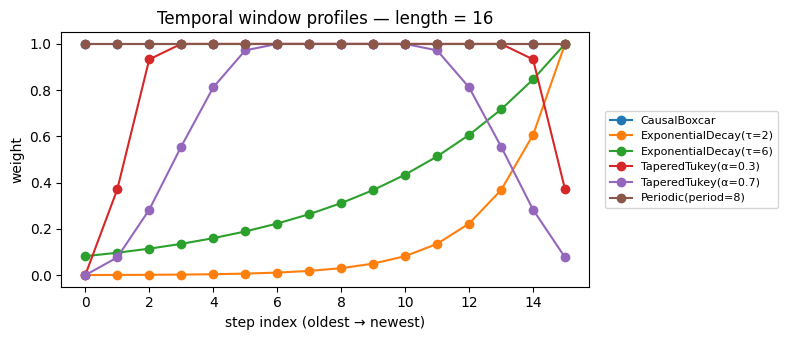

In [2]:
geom = TemporalFixedLookback(length=16)
length = 16

temporal_windows = {
    "CausalBoxcar": TemporalCausalBoxcar(),
    "ExponentialDecay(τ=2)": TemporalExponentialDecay(tau=2.0),
    "ExponentialDecay(τ=6)": TemporalExponentialDecay(tau=6.0),
    "TaperedTukey(α=0.3)": TemporalTaperedTukey(alpha=0.3),
    "TaperedTukey(α=0.7)": TemporalTaperedTukey(alpha=0.7),
    "Periodic(period=8)": TemporalPeriodic(period=8),
}

fig, ax = plt.subplots(figsize=(8, 3.5))
for name, w in temporal_windows.items():
    weights = w.weights(geom, length=length)
    print(f"{name:>26s}: weights.shape: {weights.shape}")
    ax.plot(weights, marker="o", label=name)
ax.set_title("Temporal window profiles — length = 16")
ax.set_xlabel("step index (oldest → newest)")
ax.set_ylabel("weight")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

## 2. Lookback windows along a 1-D NDVI-style series

A 100-step synthetic NDVI series (sinusoidal seasonality + drift)
stands in for any per-pixel temporal trace.

series.shape: (100,)
len(patches): 9
patches[0].data.shape: (10,)


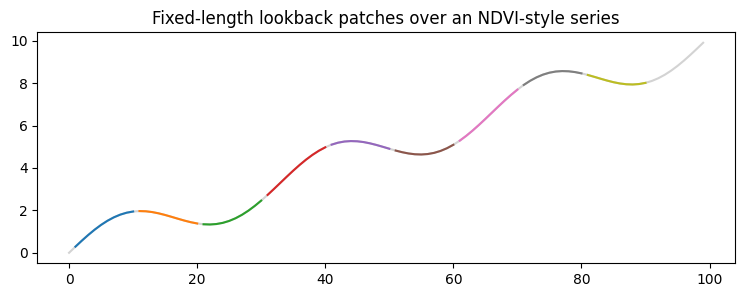

In [3]:
series = np.sin(np.linspace(0, 6 * np.pi, 100)) + 0.1 * np.arange(100)
print(f"series.shape: {series.shape}")

tp = TemporalPatcher(
    geometry=TemporalFixedLookback(length=10),
    sampler=TemporalRegularStride(step=10),
    window=TemporalCausalBoxcar(),
    aggregation=TemporalMean(),
)
patches = [p for p in tp.split(series) if p.data.shape[0] == 10]
print(f"len(patches): {len(patches)}")
print(f"patches[0].data.shape: {patches[0].data.shape}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(series, color="lightgray", label="series")
for p in patches:
    s = p.indices
    ax.plot(np.arange(s.start, s.stop), p.data, lw=1.5)
ax.set_title("Fixed-length lookback patches over an NDVI-style series")
plt.show()

## 3. `TemporalFold` — stateful, RNN-like reduction

Patches are folded sequentially with caller-supplied state. The
canonical use case is per-pixel rolling statistics (running mean,
running max, exponentially-smoothed forecast, …).

In [4]:
running_sum = TemporalPatcher(
    geometry=TemporalFixedLookback(length=1),
    sampler=TemporalRegularStride(step=1),
    window=TemporalCausalBoxcar(),
    aggregation=TemporalFold(
        fold_fn=lambda s, p: (s or 0.0) + float(p.data[0]),
        initial_state=0.0,
    ),
)
total = running_sum.merge(list(running_sum.split(series)))
print(f"running sum at end: {total:.3f}")
print(f"np.sum(series)    : {series.sum():.3f}")

running sum at end: 495.000
np.sum(series)    : 495.000


## 4. Forecasting with `TemporalLookbackHorizon`

Each patch carries lookback + horizon. The `TemporalForecast`
aggregation keeps only the horizon block per anchor.

In [5]:
forecast = TemporalPatcher(
    geometry=TemporalLookbackHorizon(lookback=5, horizon=3),
    sampler=TemporalRegularStride(step=8),
    window=TemporalCausalBoxcar(),
    aggregation=TemporalForecast(horizon=3),
)
patches_lh = list(forecast.split(series))
print(f"len(patches_lh): {len(patches_lh)}")
print(f"patches_lh[1].data.shape: {patches_lh[1].data.shape}")

# A trivial "model": copy the lookback's last value into the horizon.
predictions = []
for p in patches_lh:
    arr = np.asarray(p.data)
    if arr.shape[0] < 8:
        continue
    last = arr[4]
    pred = np.array([arr[0], arr[1], arr[2], arr[3], arr[4], last, last, last])
    pred_patch = type(p)(
        data=pred, anchor=p.anchor, indices=p.indices, weights=p.weights,
    )
    predictions.append(pred_patch)
aligned = forecast.merge(predictions)
print(f"len(aligned): {len(aligned)}")
for anchor, horizon_arr in list(aligned.items())[:3]:
    print(f"  anchor={anchor}: horizon.shape={horizon_arr.shape}")

len(patches_lh): 13
patches_lh[1].data.shape: (8,)
len(aligned): 12
  anchor=8: horizon.shape=(3,)
  anchor=16: horizon.shape=(3,)
  anchor=24: horizon.shape=(3,)


## 5. `SpatioTemporalPatcher` over a real S2 time stack

Pull eight cloud-free Sentinel-2 acquisitions over Lake Tahoe
(June–July 2024) — `load_s2_timestack` returns a `(T, C, H, W)`
`uint16` array plus a date list. We compose a `SpatialPatcher`
(256×256 chips) with a `TemporalPatcher` (4-date causal lookback)
under the **product coupling** — every spatial patch is paired with
every temporal patch.

stack shape: (8, 2, 3935, 1599)  dates: ['2024-06-02', '2024-06-04', '2024-06-07', '2024-06-09', '2024-06-12', '2024-06-14', '2024-06-17', '2024-06-19']
nir_stack shape: (8, 512, 512)
product coupling: 8 space×time patches
  first.data.shape: (1, 256, 256)
  first.(space, time): ((0, 0), 0)


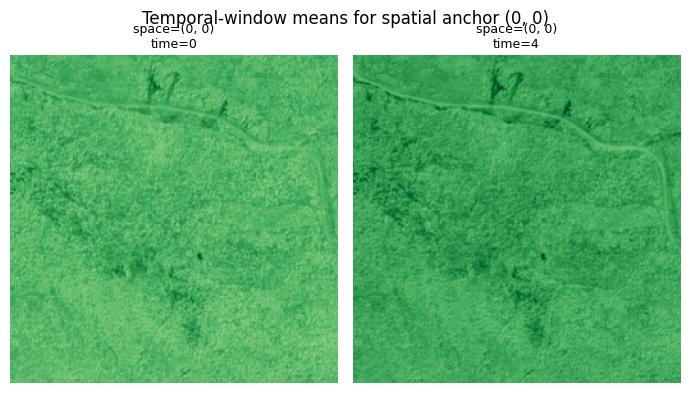

In [6]:
stack, dates, ref_da = load_s2_timestack(
    bbox=LAKE_TAHOE_BBOX,
    date_range="2024-06-01/2024-07-31",
    tile=LAKE_TAHOE_TILE,
    bands=("B04", "B08"),
    max_items=8,
    max_cloud_cover=20.0,
)
print(f"stack shape: {stack.shape}  dates: {dates}")

# Reduce to a single-band per-time NIR proxy (just B08) and shrink the
# spatial extent for a snappier demo.
nir_stack = stack[:, 1, :512, :512].astype("float32") * 1e-4  # (T, H, W)
print(f"nir_stack shape: {nir_stack.shape}")

# Wrap as a 3D RasterField (T as the leading "band" axis).
field3d = RasterField(
    GeoTensor(
        values=nir_stack,
        transform=ref_da.rio.transform(),
        crs=ref_da.rio.crs,
        fill_value_default=0.0,
    )
)

sp = SpatialPatcher(
    geometry=SpatialRectangular(size=(256, 256)),
    sampler=SpatialRegularStride(step=256),
    window=SpatialBoxcar(),
    aggregation=SpatialOverlapAdd(),
)
tp = TemporalPatcher(
    geometry=TemporalFixedLookback(length=4),
    sampler=TemporalRegularStride(step=4),
    window=TemporalCausalBoxcar(),
    aggregation=TemporalMean(),
)
stp = SpatioTemporalPatcher(spatial=sp, temporal=tp, coupling="product")

patches3 = list(stp.split(field3d))
print(f"product coupling: {len(patches3)} space×time patches")
print(f"  first.data.shape: {patches3[0].data.shape}")
print(f"  first.(space, time): ({patches3[0].space}, {patches3[0].time})")

# Visualise the per-anchor temporal means of one spatial chip
# (the upper-left 256×256 corner).
import collections

by_space = collections.defaultdict(list)
for p in patches3:
    by_space[p.space].append(p)

target_space = next(iter(by_space))
chips_for_corner = by_space[target_space]
fig, axes = plt.subplots(1, len(chips_for_corner), figsize=(3.5 * len(chips_for_corner), 4))
for ax, p in zip(np.atleast_1d(axes), chips_for_corner, strict=True):
    mean_chip = p.data.mean(axis=0)  # average across the t-window
    ax.imshow(mean_chip, cmap="Greens", vmin=0, vmax=0.5)
    ax.set_title(f"space={p.space}\ntime={p.time}", fontsize=9)
    ax.axis("off")
plt.suptitle(f"Temporal-window means for spatial anchor {target_space}")
plt.tight_layout()
plt.show()

## 6. Coupled coupling — event-triggered patching

`coupling="coupled"` lets you specify explicit (space, time)
pairs — useful for event-triggered analysis (e.g. "look at chip X
only after acquisition Y"). Three events on the Lake Tahoe stack:

In [7]:
sp_explicit = SpatialPatcher(
    geometry=SpatialRectangular(size=(256, 256)),
    sampler=SpatialExplicit(
        anchors_=[((0, 0), 1), ((0, 256), 3), ((256, 0), 5)]
    ),
    window=SpatialBoxcar(),
    aggregation=SpatialOverlapAdd(),
)
stp_c = SpatioTemporalPatcher(
    spatial=sp_explicit,
    temporal=TemporalPatcher(
        geometry=TemporalFixedLookback(length=2),
        sampler=TemporalRegularStride(step=1),
        window=TemporalCausalBoxcar(),
        aggregation=TemporalMean(),
    ),
    coupling="coupled",
)
events = list(stp_c.split(field3d))
print(f"coupled events: {len(events)}")
for e in events:
    print(f"  space={e.space} time={e.time}  data.shape={e.data.shape}")

coupled events: 3
  space=(0, 0) time=1  data.shape=(2, 256, 256)
  space=(0, 256) time=3  data.shape=(2, 256, 256)
  space=(256, 0) time=5  data.shape=(2, 256, 256)


## Recap

Same four-axis machinery as the spatial case, applied along the
time axis (geometry, sampler, window, aggregation) — plus a
`SpatioTemporalPatcher` that composes the two. Three coupling
modes:

| Coupling | Meaning | Example |
|---|---|---|
| `product` | every space × every time | Dense space-time inference. |
| `aligned` | one-to-one along the iteration axis | Walking a single trajectory through space-time. |
| `coupled` | explicit (space, time) pairs | Event-triggered analysis. |

For the *applied* version of this — running NDVI per chip across a
real time stack and stitching back into a global animation — see
[`../05_patching_grids`](../05_patching_grids.ipynb) and the
`geocatalog.load_raster_timeseries` walk in
[`../catalog/01_intro`](../catalog/01_intro.ipynb).